In [1]:
import torch
import torch.nn as nn

class DropoutNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 20)
        # Randomly drops 50% of the neurons during training
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(20, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x) # 50% of values become 0.0 here
        x = self.fc2(x)
        return x

dummy_x = torch.randn(1, 10)
model = DropoutNetwork()

# 1. TRAINING MODE (Dropout is ACTIVE)
model.train()
print("Training Output:", model(dummy_x))

# 2. EVALUATION MODE (Dropout is DISABLED)
# CRITICAL: Always do this before deploying or testing!
model.eval()
print("Evaluation Output:", model(dummy_x))

Training Output: tensor([[-0.2371, -0.3822]], grad_fn=<AddmmBackward0>)
Evaluation Output: tensor([[-0.0253, -0.4475]], grad_fn=<AddmmBackward0>)


In [3]:
class BatchNormNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(100, 64)
        # Applies BatchNorm to the 64 features
        self.bn = nn.BatchNorm1d(num_features=64)
        self.relu = nn.ReLU()

    def forward(self, x):
        # The standard order: Linear -> BatchNorm -> Activation
        x = self.fc1(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

# Notice we need a batch size > 1 to calculate a meaningful mean/variance
dummy_batch = torch.randn(32, 100)
model = BatchNormNetwork()
output = model(dummy_batch)

output

tensor([[0.0000, 2.3340, 0.8652,  ..., 0.4289, 0.3755, 1.2748],
        [0.0000, 1.2627, 1.8536,  ..., 0.0000, 0.6653, 0.0000],
        [0.4857, 1.1315, 0.0000,  ..., 1.0531, 0.7225, 0.0000],
        ...,
        [0.0000, 0.0000, 0.3494,  ..., 0.5839, 0.7436, 0.0000],
        [0.3298, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.3926],
        [0.0000, 0.8253, 0.1329,  ..., 0.5623, 0.0000, 0.0000]],
       grad_fn=<ReluBackward0>)

In [4]:
class LayerNormNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # E.g., a word embedding of size 256
        self.embedding = nn.Linear(100, 256)
        # Normalizes ACROSS the 256 features for each sample individually
        self.ln = nn.LayerNorm(normalized_shape=256)

    def forward(self, x):
        x = self.embedding(x)
        x = self.ln(x)
        return x

# Even with a tiny batch size of 2, LayerNorm works perfectly
dummy_sequence = torch.randn(2, 100)
model = LayerNormNetwork()
output = model(dummy_sequence)
ouput

NameError: name 'ouput' is not defined

In [6]:
class LayerNormNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # E.g., a word embedding of size 256
        self.embedding = nn.Linear(100, 256)
        # Normalizes ACROSS the 256 features for each sample individually
        self.ln = nn.LayerNorm(normalized_shape=256)

    def forward(self, x):
        x = self.embedding(x)
        x = self.ln(x)
        return x

# Even with a tiny batch size of 2, LayerNorm works perfectly
dummy_sequence = torch.randn(2, 100)
model = LayerNormNetwork()
output = model(dummy_sequence)
output

tensor([[-0.5643, -1.1569, -0.5551,  0.4732, -0.9964,  0.0583,  1.4491, -0.8928,
         -0.9928,  0.0070,  0.2762, -2.3453, -0.6108,  0.1789, -0.6734,  1.0997,
          0.1170,  0.7630,  0.5714, -1.0130, -1.7327,  0.7525,  0.7744, -0.5342,
          0.6131,  0.7041,  0.6495, -0.1301, -0.2034, -0.5194, -1.7788,  0.0768,
          0.0417,  0.2965,  0.8497,  0.1560,  1.5009,  1.0016,  0.4293,  1.2589,
         -1.1238,  2.5329, -1.1473,  0.5943, -0.5186,  1.5198,  1.4667, -0.8141,
          0.2482,  0.2603, -0.0388,  0.0247, -1.0214,  0.5018,  1.2793, -0.3125,
          1.9473,  1.8996, -0.5539, -0.8302,  0.5816, -1.5984,  0.0239, -0.2726,
         -0.9216, -1.7389, -0.3108, -0.3027,  2.5261, -0.8804,  0.3397, -0.6898,
          0.5295,  0.1025, -0.8641, -1.1074, -0.1130, -1.2884,  0.7944, -1.0608,
          0.8421, -1.5953,  2.2783,  1.2537,  0.3370,  1.8210,  0.8984, -0.5099,
          0.5327, -0.4268,  2.6158,  0.5616, -1.5930,  0.1225, -1.2755,  0.1094,
          0.2283, -0.3444, -

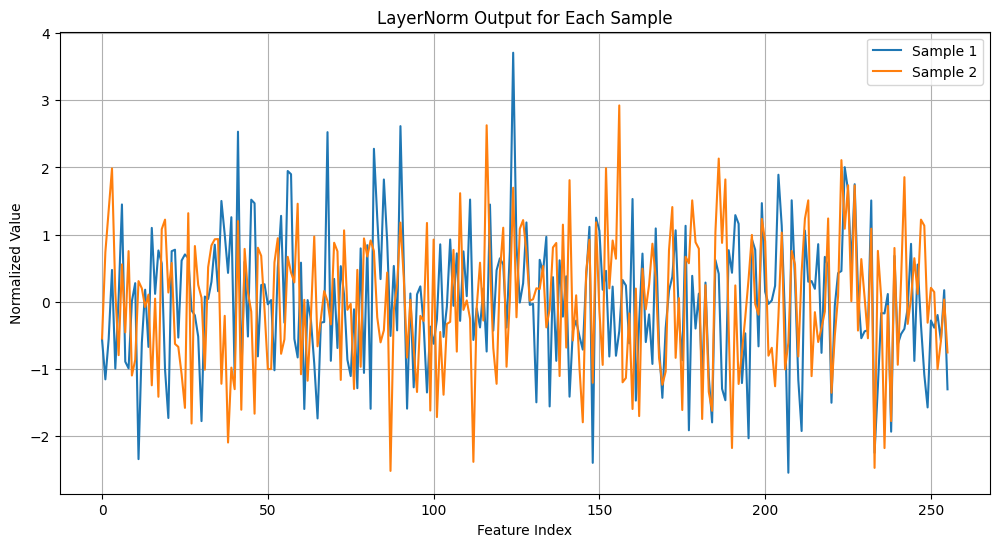

In [7]:
import matplotlib.pyplot as plt

output_np = output.detach().numpy()

plt.figure(figsize=(12, 6))
for i in range(output_np.shape[0]):
    plt.plot(output_np[i], label=f'Sample {i+1}')

plt.title('LayerNorm Output for Each Sample')
plt.xlabel('Feature Index')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)
plt.show()